In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
url = "https://www.data.gouv.fr/api/1/datasets/allergen-chip-challenge/"

In [45]:
df_principal = pd.read_csv("../data/allergenchipchallenge-data-corrected-final-hdh-sfa (2).csv", sep=";")
df_principal.head()

/tmp/ipykernel_43275/2529463902.py:1: DtypeWarning: Columns (9,10,11,13,14,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255) have mixed types. Specify dtype option on import or set low_memory=False.
  df_principal = pd.read_csv("../data/allergenchipchallenge-data-corrected-final-hdh-sfa (2).csv", sep=";")


,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,...,Man_i,Mel_g,Mes_a_1_RUO,Mor_r,Mus_a,Myt_e,Ole_e_7_RUO,Ori_v,Ory_c_1,Ory_c_2
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# Création du dictionnaire de correspondance
# Ici, nous créons manuellement un dictionnaire de correspondance basé sur les standards ISAC.
# Si votre fichier 'df_dict' contient déjà ces colonnes, on pourra automatiser cette partie.
mapping_categories = {
    # POLLENS D'ARBRES
    'Aln_g_1': 'Pollens', 'Bet_v_1': 'Pollens', 'Bet_v_2': 'Pollens', 'Bet_v_4': 'Pollens',
    'Cup_a_1': 'Pollens', 'Ole_e_1': 'Pollens', 'Ole_e_7': 'Pollens', 'Ole_e_9': 'Pollens',
    'Cor_a_1.0101': 'Pollens', 'Cor_a_1.0401': 'Pollens',
    
    # GRAMINÉES ET HERBACÉES
    'Amb_a_1': 'Pollens', 'Art_v_1': 'Pollens', 'Art_v_3': 'Pollens',
    'Phl_p_1': 'Pollens', 'Phl_p_2': 'Pollens', 'Phl_p_4': 'Pollens', 'Phl_p_5': 'Pollens',
    'Phl_p_6': 'Pollens', 'Phl_p_7': 'Pollens', 'Phl_p_11': 'Pollens', 'Phl_p_12': 'Pollens',
    'Che_a_1': 'Pollens', 'Par_j_2': 'Pollens',

    # ALIMENTS (Fruits, Légumes, Graines)
    'Act_d_1': 'Aliments', 'Act_d_2': 'Aliments', 'Act_d_5': 'Aliments', 'Act_d_8': 'Aliments',
    'Ana_o_2': 'Aliments', 'Api_g_1': 'Aliments', 
    'Ara_h_1': 'Aliments', 'Ara_h_2': 'Aliments', 'Ara_h_3': 'Aliments', 'Ara_h_6': 'Aliments', 'Ara_h_8': 'Aliments', 'Ara_h_9': 'Aliments',
    'Ber_e_1': 'Aliments', 'Cor_a_8': 'Aliments', 'Cor_a_9': 'Aliments', 'Cor_a_14': 'Aliments',
    'Gly_m_4': 'Aliments', 'Gly_m_5': 'Aliments', 'Gly_m_6': 'Aliments',
    'Mal_d_1': 'Aliments', 'Pru_p_3': 'Aliments', 'Ses_i_1': 'Aliments', 'Sin_a_1': 'Aliments',
    
    # PRODUITS ANIMAUX (Lait, Œuf, Viande, Poisson)
    'Bos_d_4': 'Aliments', 'Bos_d_5': 'Aliments', 'Bos_d_6': 'Aliments', 'Bos_d_8': 'Aliments', 'Bos_d_Lactoferrin': 'Aliments',
    'Gal_d_1': 'Aliments', 'Gal_d_2': 'Aliments', 'Gal_d_3': 'Aliments', 'Gal_d_5': 'Aliments',
    'Gad_m_1': 'Aliments', 'Pen_m_1': 'Aliments', 'Pen_m_2': 'Aliments', 'Pen_m_4': 'Aliments',
    
    # ANIMAUX DOMESTIQUES
    'Can_f_1': 'Animaux', 'Can_f_2': 'Animaux', 'Can_f_3': 'Animaux', 'Can_f_5': 'Animaux', 'Can_f_6': 'Animaux',
    'Fel_d_1': 'Animaux', 'Fel_d_2': 'Animaux', 'Fel_d_4': 'Animaux', 'Fel_d_7': 'Animaux',
    'Equ_c_1': 'Animaux', 'Mus_m_1': 'Animaux',

    # ACARIENS ET BLATTES
    'Der_f_1': 'Acariens/Blattes', 'Der_f_2': 'Acariens/Blattes',
    'Der_p_1': 'Acariens/Blattes', 'Der_p_2': 'Acariens/Blattes', 'Der_p_10': 'Acariens/Blattes',
    'Bla_g_1': 'Acariens/Blattes', 'Bla_g_2': 'Acariens/Blattes', 'Bla_g_5': 'Acariens/Blattes', 'Bla_g_7': 'Acariens/Blattes',
    'Blo_t_5': 'Acariens/Blattes', 'Lep_d_2': 'Acariens/Blattes',

    # MOISISSURES, VENINS ET LATEX
    'Alt_a_1': 'Moisissures/Autres', 'Alt_a_6': 'Moisissures/Autres',
    'Asp_f_1': 'Moisissures/Autres', 'Asp_f_3': 'Moisissures/Autres', 'Asp_f_6': 'Moisissures/Autres',
    'Cla_h_8': 'Moisissures/Autres', 'Pen_c_3': 'Moisissures/Autres',
    'Api_m_1': 'Moisissures/Autres', 'Api_m_4': 'Moisissures/Autres',
    'Vesp_v_1': 'Moisissures/Autres', 'Vesp_v_5': 'Moisissures/Autres',
    'Hev_b_1': 'Moisissures/Autres', 'Hev_b_3': 'Moisissures/Autres', 'Hev_b_5': 'Moisissures/Autres', 'Hev_b_6.02': 'Moisissures/Autres',
    'Ani_s_1': 'Moisissures/Autres', 'Ani_s_3': 'Moisissures/Autres',
    'Hom_s_LF': 'Moisissures/Autres'
}



In [47]:


# NETTOYAGE ET CONVERSION DES DONNÉES

# Identification des colonnes de métadonnées des patients (à ne pas sommer)
colonnes_metadonnees = [
    'Patient_ID', 'Chip_Type', 'Age', 'Gender', 'Blood_Month_sample',
    'French_Residence_Department', 'French_Region', 'Rural_or_urban_area',
    'Sensitization', 'Treatment_of_rhinitis', 'Treatment_of_athsma',
    'Age_of_onsets', 'Skin_Symptoms', 'General_cofactors', 'Treatment_of_atopic_dematitis'
]

# Sélection unique des colonnes d'allergènes présentes dans le fichier principal
colonnes_allergenes_presentes = [col for col in df_principal.columns if col in mapping_categories]

# Création d'une copie propre pour travailler
df_clean = df_principal.copy()

# Conversion des virgules en points pour toutes les colonnes d'allergènes (ex: "7,38" -> 7.38)
for col in colonnes_allergenes_presentes:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.', regex=False)
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0.0)


In [48]:
# Extraction des métadonnées des patients
df_final = df_clean[colonnes_metadonnees].copy()

In [49]:
# Groupement horizontal (axis=1) des allergènes par leur catégorie en calculant la SOMME
# (Vous pouvez remplacer .sum() par .max() si vous voulez le score maximal de la catégorie)
df_categories_somme = df_clean[colonnes_allergenes_presentes].groupby(mapping_categories, axis=1).sum()

/tmp/ipykernel_43275/3003629868.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_categories_somme = df_clean[colonnes_allergenes_presentes].groupby(mapping_categories, axis=1).sum()


In [50]:
# Fusion des métadonnées et des scores par grandes catégories
df_resultat_complet = pd.concat([df_final, df_categories_somme], axis=1)

In [51]:
# Affichage des 5 premières lignes dans le notebook pour vérification
print("Aperçu du nouveau tableau regroupé par catégories :")
display(df_resultat_complet.head())

Aperçu du nouveau tableau regroupé par catégories :


,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_athsma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9,9,9,9,0,9,0.43,0.00,0.00,0.0,0.00
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,77.91,0.00,0.0,168.54
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2,9,0,9,5,9,0.00,0.00,0.00,0.0,0.00
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,34.68,20.77,0.72,0.0,268.78
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,0.00,0.00,0.0,140.05


In [52]:
# Sauvegarde du nouveau tableau dans un fichier CSV bien propre
df_resultat_complet.to_csv("allergenes_regroupes_par_categories.csv", sep=";", index=False)
print("\nLe fichier 'allergenes_regroupes_par_categories.csv' a été créé avec succès !")


Le fichier 'allergenes_regroupes_par_categories.csv' a été créé avec succès !


In [53]:
# Affiche les 50 premières lignes
display(df_resultat_complet.head(50))

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_athsma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9,9,9,9,0,9,0.43,0.00,0.00,0.00,0.00
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,77.91,0.00,0.00,168.54
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2,9,0,9,5,9,0.00,0.00,0.00,0.00,0.00
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,34.68,20.77,0.72,0.00,268.78
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,0.00,0.00,0.00,140.05
5,FHB0006,ISAC_V1,50.0,1.0,1.0,deptY,regionB,9,0,9,9,9,9,0,9,0.00,0.00,0.00,0.00,0.00
6,FHB0007,ISAC_V1,61.0,0.0,1.0,deptY,regionB,9,0,9,9,0,1,0,9,0.00,0.00,0.00,0.00,0.00
7,FHB0008,ISAC_V1,39.0,0.0,1.0,deptY,regionB,9,0,9,9,9,9,0,9,0.00,0.00,0.00,0.00,0.00
8,FHB0009,ISAC_V1,68.0,0.0,2.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,0.00,2.96,0.00,0.00
9,FHB0010,ISAC_V1,51.0,0.0,2.0,deptY,regionB,9,0,9,9,6,9,0,9,0.00,0.00,0.00,0.00,0.00


In [54]:
print(df_resultat_complet.shape)
# Résultat affiché : (nombre_de_patients, nombre_de_colonnes)

(4271, 20)


In [55]:
display(df_resultat_complet.head(4271))

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_athsma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9,9,9,9,0,9,0.43,0.00,0.00,0.00,0.00
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,77.91,0.00,0.00,168.54
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2,9,0,9,5,9,0.00,0.00,0.00,0.00,0.00
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,34.68,20.77,0.72,0.00,268.78
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,0.00,0.00,0.00,140.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,XPW0509,ISAC_V1,45.0,0.0,6.0,deptA,regionA,9,1,9,9,9,9,0,9,11.62,0.39,0.21,2.66,21.74
4267,XPW0510,ISAC_V1,44.0,0.0,6.0,deptA,regionA,9,1,9,9,9,9,0,9,13.11,0.00,0.00,0.00,0.22
4268,XPW0511,ISAC_V1,23.0,1.0,6.0,deptA,regionA,9,1,9,9,9,9,0,9,0.00,7.38,1.40,14.14,92.69
4269,XPW0512,ISAC_V1,29.0,0.0,6.0,deptA,regionA,9,1,9,9,9,9,0,9,0.00,24.37,0.00,0.00,52.06


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

In [58]:
# 1. Création d'un deuxième tableau fictif (Données Géographiques)
# Ce tableau fait le lien entre un département et sa région
donnees_regions = {
    'Departement': [75, 69, 13, 31, 44],
    'Nom_Region': ['Île-de-France', 'Auvergne-Rhône-Alpes', 'Provence-Alpes-Côte d\'Azur', 'Occitanie', 'Pays de la Loire']
}
df_regions = pd.DataFrame(donnees_regions)

print("--- Tableau des Régions (df_regions) ---")
print(df_regions)

# 2. Réalisation de la jointure (Merge)
# Imaginons que votre tableau principal 'df' possède aussi une colonne 'Departement'.
# On utilise pd.merge() pour fusionner les deux tableaux sur cette colonne commune.

# (Ligne d'exemple - elle fonctionnera si 'Departement' existe dans votre df)
# df_final = pd.merge(df, df_regions, on='Departement', how='left')

print("\n--- Explication de la fonction merge ---")
print("La commande utilisée est : df_final = pd.merge(df, df_regions, on='Departement', how='left')")

--- Tableau des Régions (df_regions) ---
   Departement                  Nom_Region
0           75               Île-de-France
1           69        Auvergne-Rhône-Alpes
2           13  Provence-Alpes-Côte d'Azur
3           31                   Occitanie
4           44            Pays de la Loire

--- Explication de la fonction merge ---
La commande utilisée est : df_final = pd.merge(df, df_regions, on='Departement', how='left')


In [59]:
# =====================================================================
# PARTIE A : Initiation au Machine Learning (Exemple avec Scikit-Learn)
# =====================================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("--- Préparation du Machine Learning ---")
# Pour faire du ML, on sépare généralement nos données :
# X = les colonnes qui servent à prédire (les indices)
# y = la colonne que l'on veut deviner (la cible)

# [Note : Ce code est un modèle théorique, il s'adaptera à tes vraies colonnes]
print("Étape 1 : Séparation des données en 'Entraînement' et 'Test'")
print("Étape 2 : Création du modèle (ex: RandomForestClassifier)")
print("Étape 3 : Entraînement du modèle avec la fonction .fit()")


--- Préparation du Machine Learning ---
Étape 1 : Séparation des données en 'Entraînement' et 'Test'
Étape 2 : Création du modèle (ex: RandomForestClassifier)
Étape 3 : Entraînement du modèle avec la fonction .fit()


In [66]:
# PARTIE B : Exportation des données pour PowerBI
# =====================================================================
# Une fois que tout ton nettoyage et tes analyses sont finis dans VS Code,
# tu dois enregistrer ton tableau final en fichier CSV.

nom_fichier_final = "donnees_pollens_propre.csv"
df = nom_fichier_final

# La fonction .to_csv() crée un vrai fichier sur ton ordinateur
df_final.to_csv(nom_fichier_final, index=False, sep=';', encoding='utf-8-sig')
# df.to_csv(nom_fichier_final, index=False, sep=';', encoding='utf-8-sig')

print("\n--- Export PowerBI ---")
print(f"Félicitations ! Le fichier '{nom_fichier_final}' a été créé.")
print("Tu peux maintenant ouvrir PowerBI et charger ce fichier pour faire tes visuels.")


--- Export PowerBI ---
Félicitations ! Le fichier 'donnees_pollens_propre.csv' a été créé.
Tu peux maintenant ouvrir PowerBI et charger ce fichier pour faire tes visuels.


In [ ]:
# AUTRE EXEMPLE DE JOINTURE 

In [1]:
import pandas as pd

# Ton tableau principal (simulé ici avec une colonne 'Departement')
donnees_pollens = {
    'Nom_Allergene': ['Bet v 1', 'Phl p 1', 'Der p 1'],
    'Departement': [75, 69, 13],
    'Concentration': [45, 12, 80]
}
df_pollens = pd.DataFrame(donnees_pollens)

# Le nouveau tableau : Données météo publiques du jour
donnees_meteo = {
    'Departement': [13, 69, 75, 44],
    'Temperature_C': [22, 19, 15, 17],
    'Vitesse_Vent_kmh': [35, 10, 5, 20]
}
df_meteo = pd.DataFrame(donnees_meteo)

# LA JOINTURE : On fusionne les deux sur la colonne commune 'Departement'
df_complet = pd.merge(df_pollens, df_meteo, on='Departement', how='left')

print("--- Tableau après jointure météo ---")
df_complet.head()

--- Tableau après jointure météo ---


,Nom_Allergene,Departement,Concentration,Temperature_C,Vitesse_Vent_kmh
0,Bet v 1,75,45,15,5
1,Phl p 1,69,12,19,10
2,Der p 1,13,80,22,35


In [2]:
# KPI 1 : La concentration maximale de pollen enregistrée
kpi_max_pollen = df_complet['Concentration'].max()

# KPI 2 : Le taux moyen de vent sur nos stations
kpi_vent_moyen = df_complet['Vitesse_Vent_kmh'].mean()

# KPI 3 : Le nombre total d'allergènes différents analysés
kpi_nb_allergenes = df_complet['Nom_Allergene'].nunique()

print("--- Vos KPIs du jour ---")
print(f"🚨 Concentration Max de Pollen : {kpi_max_pollen} grains/m³")
print(f"💨 Vitesse moyenne du vent : {kpi_vent_moyen:.1f} km/h")
print(f"🔬 Nombre d'allergènes uniques : {kpi_nb_allergenes}")

--- Vos KPIs du jour ---
🚨 Concentration Max de Pollen : 80 grains/m³
💨 Vitesse moyenne du vent : 16.7 km/h
🔬 Nombre d'allergènes uniques : 3


/tmp/ipykernel_47434/2533915713.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_complet, x='Nom_Allergene', y='Concentration', palette='viridis')


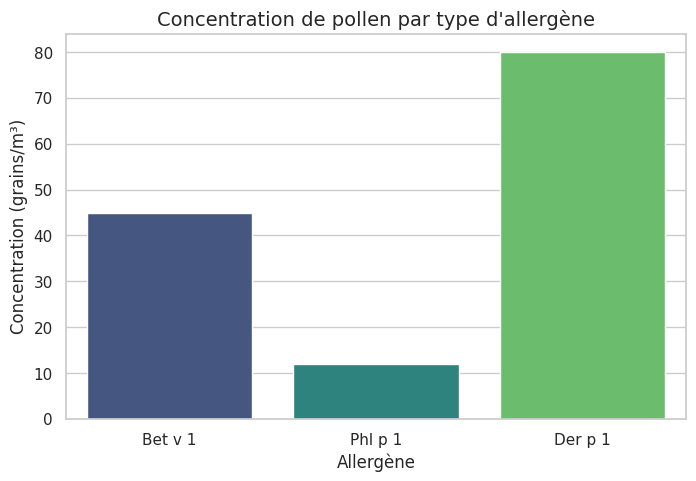

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# On configure le style du graphique
sns.set_theme(style="whitegrid")

# Création d'un graphique à barres : Concentration par Allergène
plt.figure(figsize=(8, 5))
sns.barplot(data=df_complet, x='Nom_Allergene', y='Concentration', palette='viridis')

# Ajout des titres
plt.title("Concentration de pollen par type d'allergène", fontsize=14)
plt.xlabel("Allergène", fontsize=12)
plt.ylabel("Concentration (grains/m³)", fontsize=12)

# Affichage du graphique dans VS Code
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. On prépare nos données de simulation
# X = les indices (température et vent), y = ce qu'on veut deviner (Risque Fort = 1, Faible = 0)
X = df_complet[['Temperature_C', 'Vitesse_Vent_kmh']]
y = [1, 0, 1]  # Simulation des étiquettes de risque pour l'exemple

# 2. Séparation des données (Entraînement 66% / Test 33%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# 3. Choix de l'algorithme (Forêt aléatoire)
modele = RandomForestClassifier(random_state=42)

# 4. ENTRAÎNEMENT : L'IA apprend les règles de cause à effet
modele.fit(X_train, y_train)

# 5. PRÉDICTION : On demande à l'IA de deviner sur les données de test
predictions = modele.predict(X_test)

# 6. ÉVALUATION : Est-ce que notre IA a eu juste ?
score = accuracy_score(y_test, predictions)
print(f"Précision du modèle de Machine Learning : {score * 100:.0f} %")

Précision du modèle de Machine Learning : 0 %


In [ ]:
# AUTRE exemple miniature mais complet du projet. Intégration des blocs dans le code pour faire des tests !

In [5]:
# 1. On imagine que ton df_pollens a une colonne 'Departement'
# 2. On charge les données météo (ici on simule un tableau, mais ça pourrait être un autre CSV)
import pandas as pd

donnees_meteo = {
    'Departement': [13, 69, 75, 44],
    'Temperature_C': [22, 19, 15, 17],
    'Vitesse_Vent_kmh': [35, 10, 5, 20]
}
df_meteo = pd.DataFrame(donnees_meteo)

# 3. La jointure : on fusionne tes pollens avec la météo
df_complet = pd.merge(df_pollens, df_meteo, on='Departement', how='left')
print("Jointure réussie ! Voici un aperçu :")
df_complet.head()

Jointure réussie ! Voici un aperçu :


,Nom_Allergene,Departement,Concentration,Temperature_C,Vitesse_Vent_kmh
0,Bet v 1,75,45,15,5
1,Phl p 1,69,12,19,10
2,Der p 1,13,80,22,35


In [6]:
# Remplace 'Concentration' par le vrai nom de ta colonne de scores de pollens
kpi_max_pollen = df_complet['Concentration'].max()
kpi_vent_moyen = df_complet['Vitesse_Vent_kmh'].mean()
kpi_total_analyses = len(df_complet)

print(f"🚨 Concentration Maximale détectée : {kpi_max_pollen} grains/m³")
print(f"💨 Vitesse moyenne du vent : {kpi_vent_moyen:.1f} km/h")
print(f"📊 Nombre total de prélèvements analysés : {kpi_total_analyses}")

🚨 Concentration Maximale détectée : 80 grains/m³
💨 Vitesse moyenne du vent : 16.7 km/h
📊 Nombre total de prélèvements analysés : 3


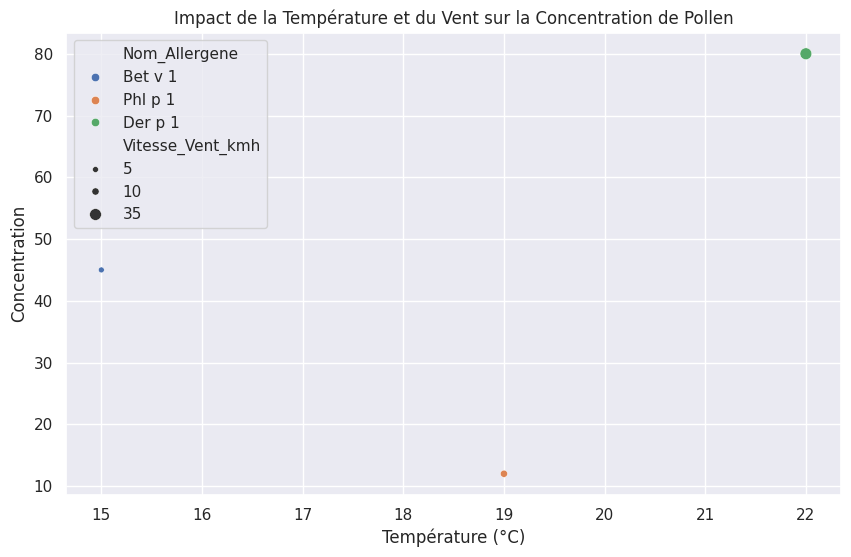

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# On définit le style
sns.set_theme(style="darkgrid")

# On crée un graphique : Température vs Concentration de Pollen
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_complet, x='Temperature_C', y='Concentration', hue='Nom_Allergene', size='Vitesse_Vent_kmh')

plt.title("Impact de la Température et du Vent sur la Concentration de Pollen")
plt.xlabel("Température (°C)")
plt.ylabel("Concentration")

# Cette ligne affiche le graphique directement sous ta cellule dans VS Code
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. On crée une colonne cible : Risque (1 si Concentration > 40, sinon 0)
df_complet['Risque_Eleve'] = (df_complet['Concentration'] > 40).astype(int)

# 2. Nos variables prédictives (X) et notre cible (y)
X = df_complet[['Temperature_C', 'Vitesse_Vent_kmh']]
y = df_complet['Risque_Eleve']

# 3. Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entraînement du modèle
modele = RandomForestClassifier()
modele.fit(X_train, y_train)

# 5. Score de précision
precision = modele.score(X_test, y_test)
print(f"Le modèle de Machine Learning a une précision de : {precision * 100:.1f}%")

Le modèle de Machine Learning a une précision de : 0.0%
